## Nonlinear Schrodinger equation

The one-dimensional time-independent nonlinear Schrödinger equation in SI units (with ħ explicitly) is:

$$
    -\frac{\hbar^2}{2m} \frac{d^2\psi}{dx^2} + V(x)\psi + g|\psi|^2\psi = E\psi
$$


Let's introduce the following dimensionless quantities:

\begin{cases}
    x' = x / L \\
    \psi'(x') = \sqrt{L} \, \psi(L x') \\
    V'(x') = V(L x') / \frac{\hbar ^ 2}{2 m L ^ 2} \\
    E' = E / \frac{\hbar ^ 2}{2 m L ^ 2} \\
    g' = g / \frac{\hbar ^ 2}{2 m L}
\end{cases}

So we get the dimensionless form:

The dimensionless quantities you introduced work correctly. Substituting them into the time-independent nonlinear Schrödinger equation yields the dimensionless form:

$$
    -\frac{d^2\psi'}{dx'^2} + V'(x')\psi' + g'|\psi'|^2\psi' = E'\psi'
$$

We're going to solve it applying homogeneous Dirichlet boundary conditions and without the potential $V$.

We discretize the dimensionless equation:  

$$
    -\psi'' + g\,|\psi|^2\psi = E\psi
$$  

On the interval $x\in[0,1]$ with homogeneous Dirichlet conditions $\psi(0)=\psi(1)=0$.

Using a uniform grid with $N$ interior points:  

$$
    x_i = i\,h,\quad h = \frac{1}{N+1},\quad i=0,\dots,N+1
$$

Where $\psi_0 = 0,\ \psi_{N+1}=0$.  


The central difference approximation for the second derivative is:  

$$
    \psi''(x_i) \approx \frac{\psi_{i+1} - 2\psi_i + \psi_{i-1}}{h^2}
$$  

Substituting into the equation at interior point $i$ gives:  

$$
    -\frac{\psi_{i+1} - 2\psi_i + \psi_{i-1}}{h^2} + g\,|\psi_i|^2\psi_i = E\,\psi_i
$$  

Multiply through by $h^2$:  

$$
    -\bigl(\psi_{i+1} - 2\psi_i + \psi_{i-1}\bigr) + g\,h^2\,|\psi_i|^2\psi_i = E\,h^2\,\psi_i
$$  

Rearranging:  

$$
    2\psi_i - \psi_{i-1} - \psi_{i+1} + g\,h^2\,|\psi_i|^2\psi_i = E\,h^2\,\psi_i
$$  

Define the $N\times N$ tridiagonal matrix $T$ (the discrete negative Laplacian without the $1/h^2$ factor) as:  

$$
T = \begin{pmatrix}
2 & -1 & 0 & \cdots & 0 \\
-1 & 2 & -1 & \cdots & 0 \\
0 & -1 & 2 & \cdots & 0 \\
\vdots & \vdots & \ddots & \ddots & -1 \\
0 & 0 & \cdots & -1 & 2
\end{pmatrix}
$$  

Then $(T\psi)_i = 2\psi_i - \psi_{i-1} - \psi_{i+1}$.  

The discretized system becomes:  

$$
T\,\psi + g\,h^2\,\operatorname{diag}\bigl(|\psi|^2\bigr)\,\psi = E\,h^2\,\psi
$$  

The final matrix form is:  

$$
    \boxed{\bigl[\,T + g h^2 \operatorname{diag}(|\psi|^2)\,\bigr]\,\psi = E\,h^2\,\psi, \qquad \psi_0=\psi_{N+1}=0}
$$  

This is a nonlinear eigenvalue problem where the matrix depends on the solution $\psi$. We'll solve it iteratively.

In [1]:
# Importing libraries
import numpy as np
from scipy.linalg import eigh_tridiagonal
from scipy.integrate import trapezoid

import matplotlib.pyplot as plt
plt.style.use('bmh')

In [2]:
# Function to solve the problem for a single value of g_prime
def solve(state, g, N = 250, max_iter = 100, tol = 1e-12, ret = 'None'):

    ## Initial setup of the grid ##
    x = np.linspace(0, 1, N + 2) # Domain x_prime
    h = x[1] - x[0] # dx_prime
    

    ## We solve the linear problem to find an intial solution ##

    d = np.full(N, 2.0) # Diagonal of T
    e = np.full(N - 1, - 1.0) # Offset of T
    
    E_start, psi_start = eigh_tridiagonal(d, e, select = 'i', select_range = (state, state)) # Initial guess

    E_start *= (h ** 2) # Dimensionless energy E_prime
    psi_start = psi_start.reshape(-1) # Reshaping psi_prime
    psi_start /= np.sqrt(trapezoid(psi_start ** 2, x[1:-1])) # Normalized psi_prime
    

    ## Now we solve the NLSE eigenvalue problem iteratively ##

    psi = psi_start.copy() # Initial psi_prime
    E = E_start # Initial E_prime

    for iteration in range(max_iter):
    
        V_nonlin = g * (h ** 2) * (psi ** 2) # Building the diagonal nonlinear potential: g_prime * |psi_prime|^2

        E_new, psi_new = eigh_tridiagonal(d + V_nonlin, e, select = 'i', select_range = (state, state)) # New solution

        E_new *= (h ** 2)
        psi_new = psi_new.reshape(-1)
        psi_new /= np.sqrt(trapezoid(psi_new ** 2, x[1:-1]))

        if (np.abs(E_new - E)) < tol: # Check the convergence using energy
            print(f"Converged after {iteration} iterations")
            break

        E, psi = E_new, psi_new.copy() # Continue
    
    ## Plotting ##

    plt.figure(figsize = (8, 5))
    plt.plot(x[1:-1], psi_start, 'k--', linewidth = 2, label = r"Linear $\psi'$")
    plt.plot(x[1:-1], psi, 'r-', linewidth = 2, label = r"NLSE $\psi'$")
    plt.xlabel(r"$x'$", fontsize = 14)
    plt.ylabel(r"$\psi'(x')$", fontsize = 14)
    plt.title(f"NLSE solution for state {state} and g' = {g}", fontsize = 12)
    plt.grid(True, alpha = 0.7)
    plt.legend(loc = 'best')
    plt.tight_layout()
    plt.show()

    return None

Converged after 9 iterations


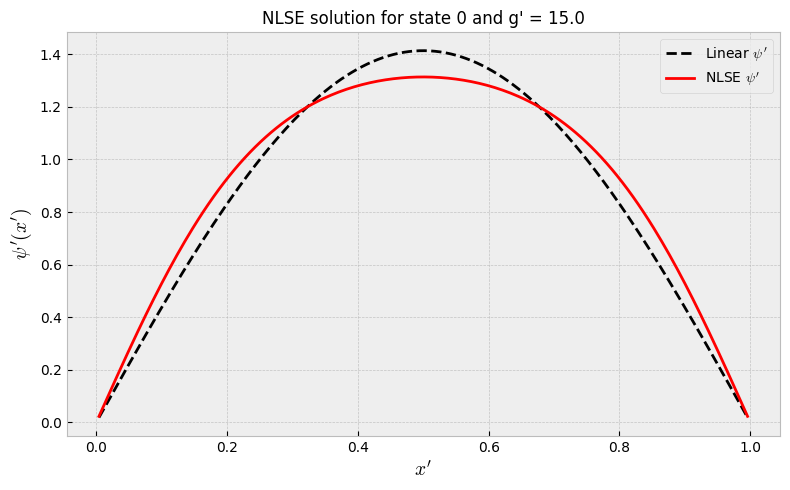

In [3]:
solve(g = 15.0, state = 0) # g positive, ground state

Converged after 3 iterations


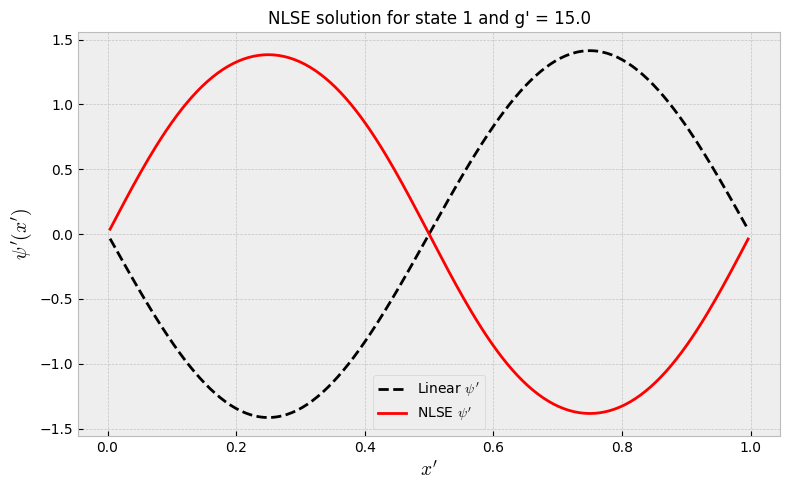

In [4]:
solve(g = 15.0, state = 1) # g positive, first state

Converged after 8 iterations


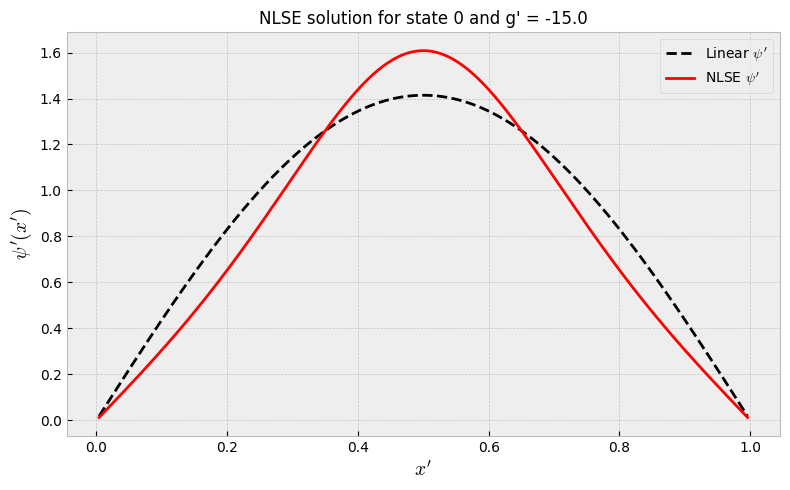

In [5]:
solve(g = - 15.0, state = 0) # g negative, ground state

Converged after 3 iterations


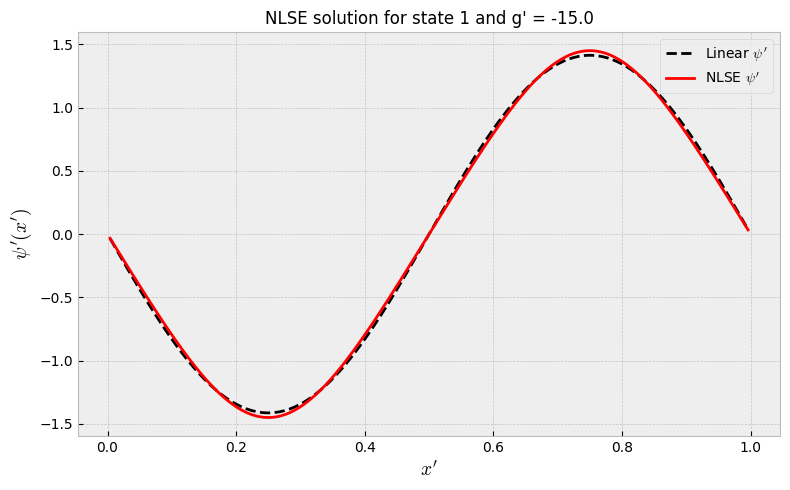

In [6]:
solve(g = - 15.0, state = 1) # g negative, first state

In [7]:
# Function to solve the problem for multiple values of g_prime
def solve_multiple_g(state, g_list, N = 250, max_iter = 100, tol = 1e-12):

    x = np.linspace(0, 1, N + 2)
    h = x[1] - x[0]

    d = np.full(N, 2.0)
    e = np.full(N - 1, -1.0)

    E_start, psi_start = eigh_tridiagonal(d, e, select = 'i', select_range = (state, state))

    E_start *= (h ** 2)
    psi_start = psi_start.reshape(-1)
    psi_start /= np.sqrt(trapezoid(psi_start ** 2, x[1:-1]))

    # Prepare the plot figure
    plt.figure(figsize = (8, 5))
    plt.plot(x[1:-1], psi_start, 'k--', linewidth = 2, label = r"Linear $\psi'$") # Plot linear solution as reference (dashed black)

    for g in g_list:     # Solving the problem for each nonlinear coupling

        psi = psi_start.copy()
        E = E_start

        for iteration in range(max_iter):

            V_nonlin = g * (h ** 2) * (psi ** 2)
            
            E_new, psi_new = eigh_tridiagonal(d + V_nonlin, e, select='i', select_range = (state, state))
            
            E_new *= (h ** 2)
            psi_new = psi_new.reshape(-1)
            psi_new /= np.sqrt(trapezoid(psi_new ** 2, x[1:-1]))

            if abs(E_new - E) < tol:
                print(f"g = {g}: converged after {iteration} iterations")
                break

            E, psi = E_new, psi_new.copy()

        plt.plot(x[1:-1], psi, linewidth = 2, label = f"g' = {g}") # Plot the converged wavefunction

    # Finalize plot
    plt.xlabel(r"$x'$", fontsize = 14)
    plt.ylabel(r"$\psi'(x')$", fontsize = 14)
    plt.title(f'NLSE solutions for state {state}', fontsize = 12)
    plt.grid(True, alpha = 0.7)
    plt.legend(loc = 'best')
    plt.tight_layout()
    plt.show()
    return None

g = 10.0: converged after 5 iterations
g = 20.0: converged after 14 iterations
g = 30.0: converged after 35 iterations
g = 40.0: converged after 37 iterations
g = 50.0: converged after 36 iterations


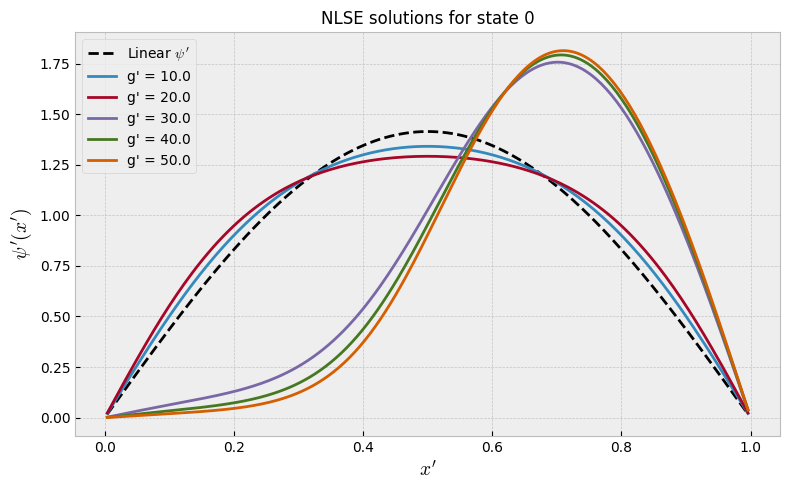

In [8]:
solve_multiple_g(state = 0, g_list = [10.0, 20.0, 30.0, 40.0, 50.0]) # g positive, ground state

g = 10.0: converged after 3 iterations
g = 20.0: converged after 4 iterations
g = 30.0: converged after 5 iterations
g = 40.0: converged after 7 iterations
g = 50.0: converged after 8 iterations


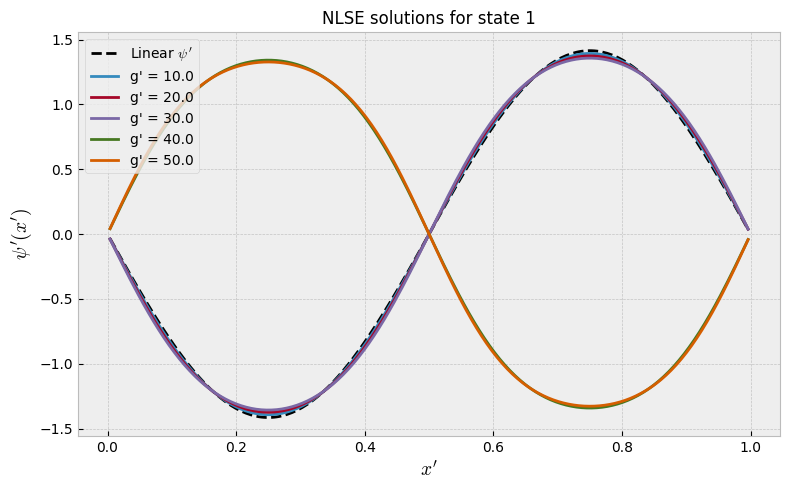

In [9]:
solve_multiple_g(state = 1, g_list = [10.0, 20.0, 30.0, 40.0, 50.0]) # g positive, first state

g = -10.0: converged after 5 iterations
g = -20.0: converged after 10 iterations
g = -30.0: converged after 15 iterations
g = -40.0: converged after 18 iterations
g = -50.0: converged after 19 iterations


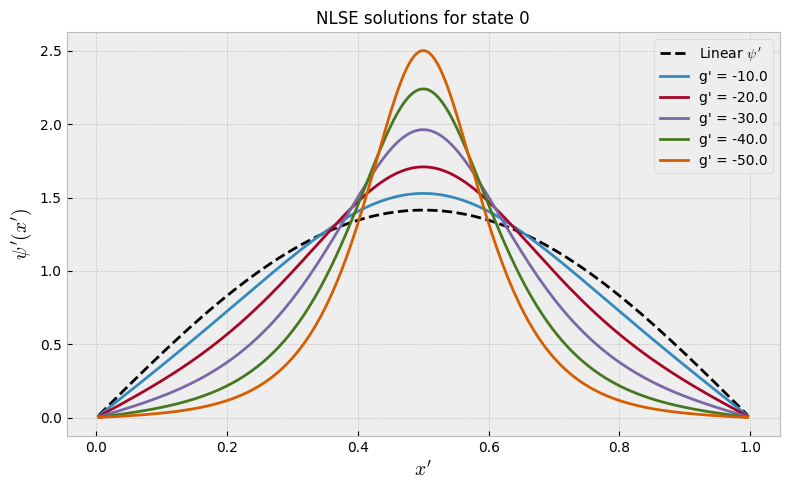

In [10]:
solve_multiple_g(state = 0, g_list = [- 10.0, - 20.0, - 30.0, - 40.0, - 50.0]) # g negative, ground state

g = -10.0: converged after 3 iterations
g = -20.0: converged after 4 iterations
g = -30.0: converged after 5 iterations
g = -40.0: converged after 6 iterations
g = -50.0: converged after 8 iterations


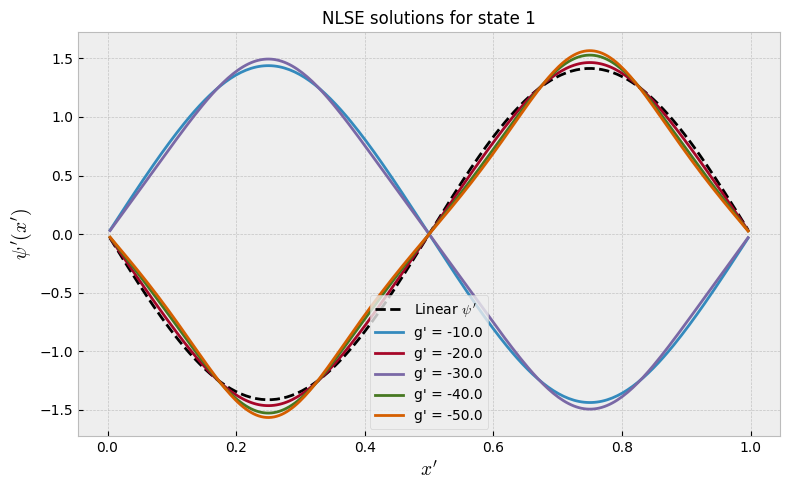

In [11]:
solve_multiple_g(state = 1, g_list = [- 10.0, - 20.0, - 30.0, - 40.0, - 50.0]) # g negative, first state

In [12]:
# Function to solve the problem for different states
def solve_multiple_states(states, g, N = 250, max_iter = 100, tol = 1e-12):

    x = np.linspace(0, 1, N + 2)          
    h = x[1] - x[0]

    d = np.full(N, 2.0) 
    e = np.full(N - 1, -1.0)            

    # Storage for solutions
    psi_solutions = []
    energies = []

    # Solving for each state
    for state in states:
        print(f"\nSolving for state {state} ...")

        E_start, psi_start = eigh_tridiagonal(d, e, select = 'i', select_range = (state, state))
        E_start *= (h ** 2)
        psi_start = psi_start.reshape(-1)
        psi_start /= np.sqrt(trapezoid(psi_start ** 2, x[1:-1]))

        psi = psi_start.copy()
        E = E_start

        for iteration in range(max_iter):

            V_nonlin = g * (h ** 2) * (psi ** 2)

            E_new, psi_new = eigh_tridiagonal(d + V_nonlin, e, select = 'i', select_range = (state, state))
            E_new *= (h ** 2)
            psi_new = psi_new.reshape(-1)
            psi_new /= np.sqrt(trapezoid(psi_new ** 2, x[1:-1]))

            if abs(E_new - E) < tol:
                print(f"Converged after {iteration} iterations")
                break

            E, psi = E_new, psi_new

        psi_solutions.append(psi)
        energies.append(E)

    plt.figure(figsize = (8, 5))
    for state, psi in zip(states, psi_solutions):
        plt.plot(x[1:-1], psi, linewidth = 2, label = f'State {state}')

    plt.xlabel(r"$x'$", fontsize = 14)
    plt.ylabel(r"$\psi'(x')$", fontsize = 14)
    plt.title(f"NLSE solutions for g' = {g}", fontsize = 12)
    plt.grid(True, alpha = 0.7)
    plt.legend(loc ='best')
    plt.tight_layout()
    plt.show()

    return None


Solving for state 0 ...
Converged after 9 iterations

Solving for state 1 ...
Converged after 3 iterations

Solving for state 2 ...
Converged after 3 iterations

Solving for state 3 ...
Converged after 2 iterations


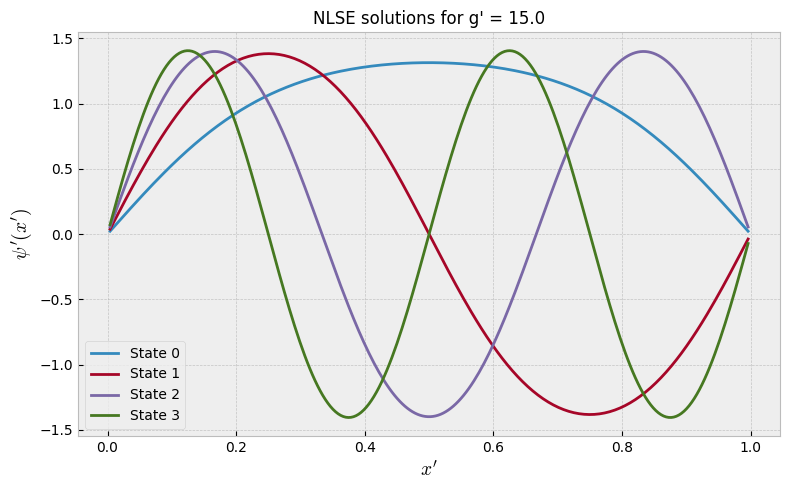

In [13]:
solve_multiple_states(states = [0, 1, 2, 3], g = 15.0) # g positive


Solving for state 0 ...
Converged after 8 iterations

Solving for state 1 ...
Converged after 3 iterations

Solving for state 2 ...
Converged after 3 iterations

Solving for state 3 ...
Converged after 2 iterations


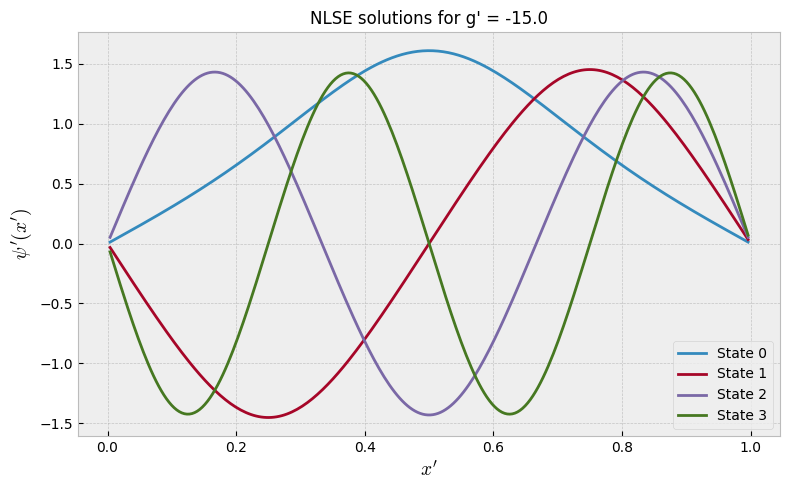

In [14]:
solve_multiple_states(states = [0, 1, 2, 3], g = - 15.0) # g negative